In [1]:
# All packages below are pre-installed on Colab; this cell makes it explicit.
# Uncomment the line below only if you hit a missing-module error.
# !pip install scikit-learn seaborn joblib --quiet

import os, io, zipfile, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                      "axes.spines.right": False})

print("✓ Imports OK")

✓ Imports OK


In [2]:
import urllib.request

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH  = "/content/uci_har.zip"
DATA_ROOT = "/content"
HAR_DIR   = "/content/UCI HAR Dataset"

if not os.path.isdir(HAR_DIR):
    print("Downloading dataset (~60 MB)…", end=" ", flush=True)
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_ROOT)
    print(f"done → {HAR_DIR}")
else:
    print("Dataset already present, skipping download.")

# Quick sanity-check
for p in ["features.txt", "activity_labels.txt",
          "train/X_train.txt", "test/X_test.txt"]:
    assert os.path.exists(os.path.join(HAR_DIR, p)), f"Missing: {p}"
print("✓ All required files present")

✓ All required files present


In [3]:
ACTIVITY_LABELS = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}

def load_features():
    path = os.path.join(HAR_DIR, "features.txt")
    features, seen = [], {}
    with open(path) as f:
        for line in f:
            _, name = line.strip().split(" ", 1)
            if name in seen:
                seen[name] += 1; name = f"{name}_{seen[name]}"
            else:
                seen[name] = 0
            features.append(name)
    return features

def load_split(split, features):
    base = os.path.join(HAR_DIR, split)
    X = pd.read_csv(f"{base}/X_{split}.txt", sep=r"\s+", header=None, names=features)
    y = pd.read_csv(f"{base}/y_{split}.txt", sep=r"\s+", header=None, names=["activity_id"])
    s = pd.read_csv(f"{base}/subject_{split}.txt", sep=r"\s+", header=None, names=["subject_id"])
    df = pd.concat([s, y, X], axis=1)
    df["activity"] = df["activity_id"].map(ACTIVITY_LABELS)
    df["split"] = split
    return df

def get_Xy(df):
    feature_cols = [c for c in df.columns
                    if c not in ("activity_id","activity","subject_id","split")]
    return df[feature_cols].values.astype(np.float32), df["activity_id"].values - 1

FEATURES    = load_features()
train_df    = load_split("train", FEATURES)
test_df     = load_split("test",  FEATURES)
X_train, y_train = get_Xy(train_df)
X_test,  y_test  = get_Xy(test_df)

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
print(f"Activities: {sorted(train_df['activity'].unique())}")
train_df[["subject_id","activity"]].head(8)

Train: (7352, 565)  |  Test: (2947, 565)
Activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


,subject_id,activity
0,1,STANDING
1,1,STANDING
2,1,STANDING
3,1,STANDING
4,1,STANDING
5,1,STANDING
6,1,STANDING
7,1,STANDING


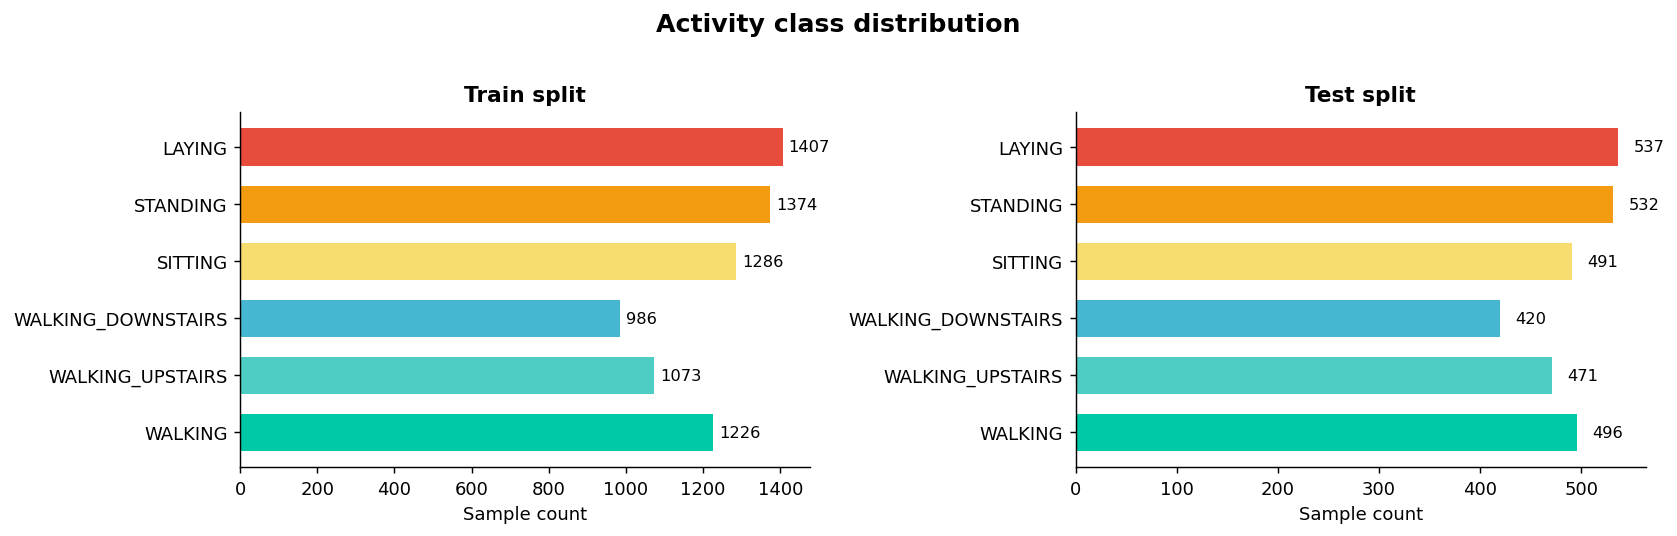

In [4]:
# ── 4a: Class distribution ────────────────────────────────────────────────────
PALETTE = ["#00C9A7","#4ECDC4","#45B7D1","#F7DC6F","#F39C12","#E74C3C"]
ACTIVITY_NAMES = ["WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS",
                  "SITTING","STANDING","LAYING"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (df, title) in zip(axes, [(train_df,"Train split"), (test_df,"Test split")]):
    counts = df["activity"].value_counts().reindex(ACTIVITY_NAMES)
    colors = [PALETTE[i] for i in range(6)]
    bars = ax.barh(ACTIVITY_NAMES, counts.values, color=colors, height=0.65, edgecolor="none")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample count")
    for bar, val in zip(bars, counts.values):
        ax.text(val + 15, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9)
fig.suptitle("Activity class distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── 4b: PCA 2D projection ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for i, activity in enumerate(ACTIVITY_NAMES):
    mask = train_df["activity"].values == activity
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=PALETTE[i], label=activity, alpha=0.4, s=7, edgecolors="none")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA — 2D projection of HAR features", fontsize=13, fontweight="bold")
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

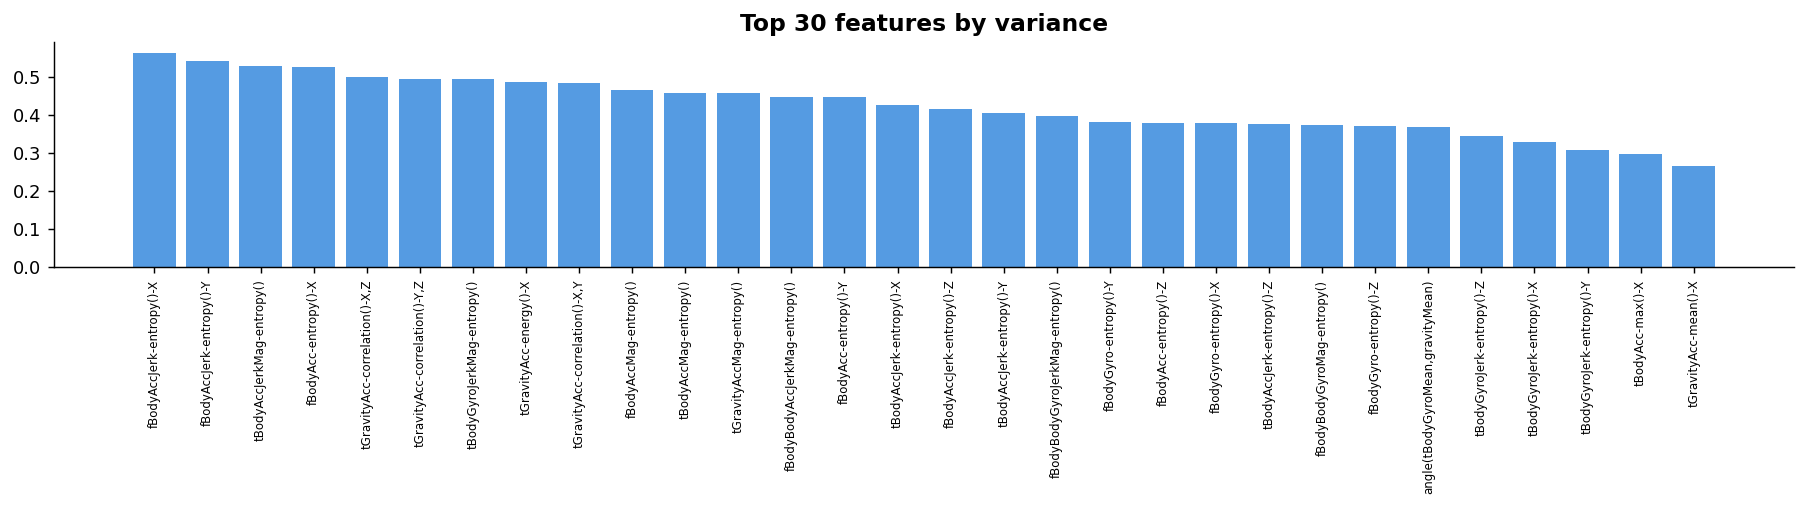

In [5]:
# ── 4c: Top-30 features by variance ──────────────────────────────────────────
feature_cols = [c for c in train_df.columns
                if c not in ("activity_id","activity","subject_id","split")]
variances = train_df[feature_cols].var().sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(30), variances.values, color="#378ADD", alpha=0.85, edgecolor="none")
ax.set_xticks(range(30))
ax.set_xticklabels(variances.index, rotation=90, fontsize=6.5)
ax.set_title("Top 30 features by variance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

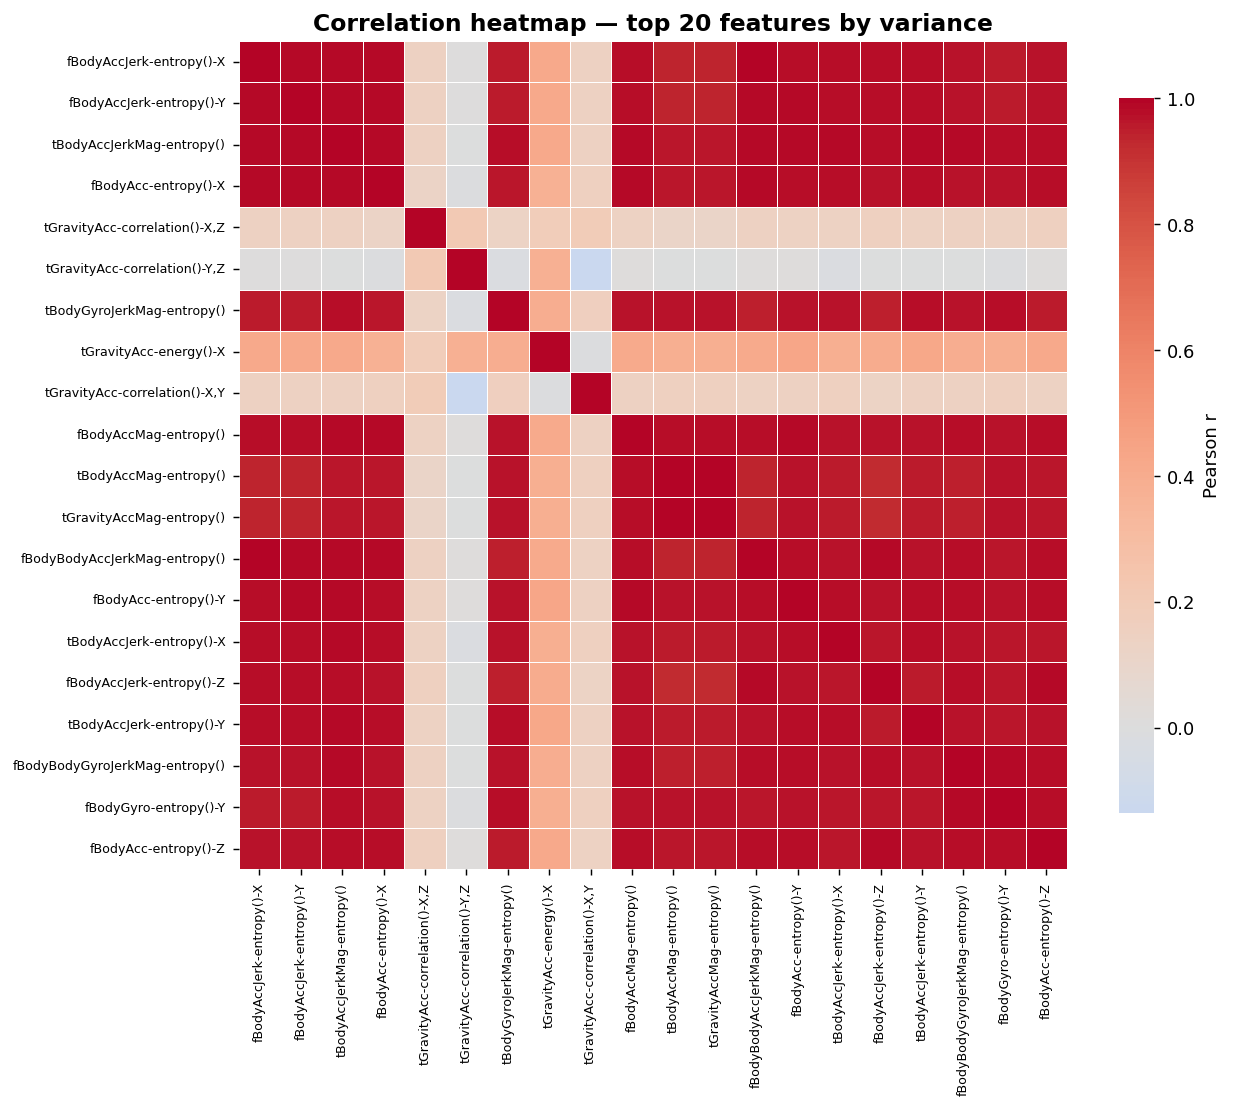

In [6]:
# ── 4d: Correlation heatmap (top-20 features) ─────────────────────────────────
top20 = train_df[feature_cols].var().sort_values(ascending=False).head(20).index
corr  = train_df[top20].corr()

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, linewidths=0.3,
            annot=False, square=True, cbar_kws={"shrink": 0.75, "label": "Pearson r"})
ax.set_title("Correlation heatmap — top 20 features by variance",
             fontsize=13, fontweight="bold")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()


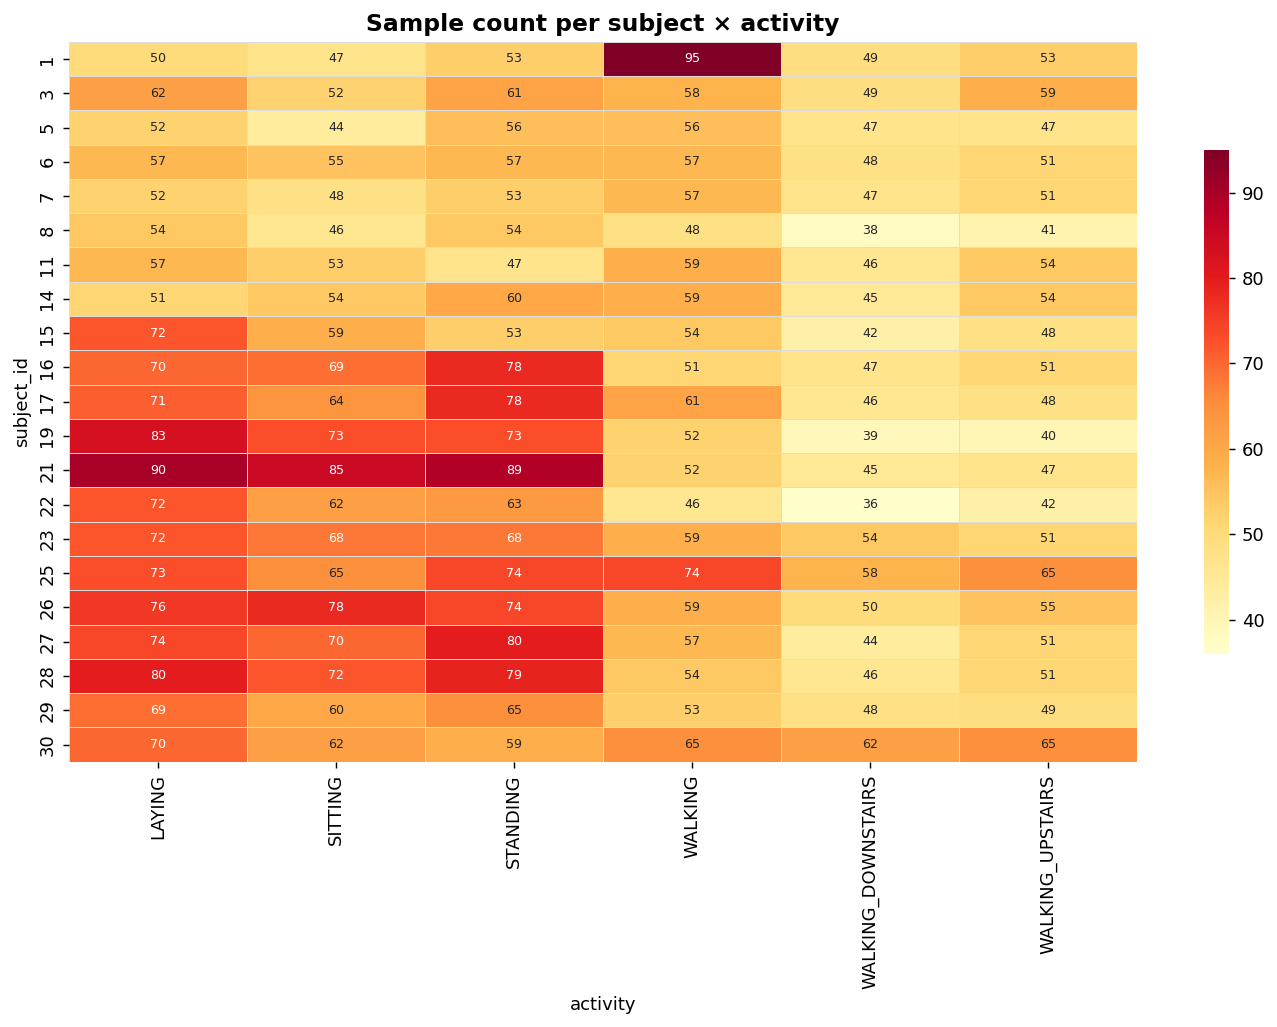

In [7]:
# ── 4e: Subject × Activity heatmap ────────────────────────────────────────────
pivot = pd.crosstab(train_df["subject_id"], train_df["activity"])

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.4, linecolor="#ddd",
            annot=True, fmt="d", annot_kws={"size": 7},
            cbar_kws={"shrink": 0.7})
ax.set_title("Sample count per subject × activity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
def build_pipelines():
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs",
                                       multi_class="multinomial", random_state=42, n_jobs=-1)),
        ]),
        "Random Forest": Pipeline([
            ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ]),
        "SVM (RBF)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True)),
        ]),
        "Gradient Boosting": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                max_depth=5, random_state=42)),
        ]),
        "KNN (k=5)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
        ]),
    }

pipelines = build_pipelines()
results   = {}

print(f"{'Model':<25}  {'Accuracy':>9}  {'F1 (macro)':>11}  {'Time':>7}")
print("-" * 60)
for name, pipe in pipelines.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0
    y_pred  = pipe.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="macro")
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    results[name] = dict(pipeline=pipe, accuracy=acc, f1_macro=f1,
                         precision=prec, recall=rec, train_time=elapsed, y_pred=y_pred)
    print(f"{name:<25}  {acc:>9.4f}  {f1:>11.4f}  {elapsed:>6.1f}s")

best_name = max(results, key=lambda k: results[k]["accuracy"])
print(f"\n★ Best model: {best_name}  (accuracy = {results[best_name]['accuracy']:.4f})")

Model                       Accuracy   F1 (macro)     Time
------------------------------------------------------------
Logistic Regression           0.9555       0.9553    18.8s
Random Forest                 0.9257       0.9238    52.1s
SVM (RBF)                     0.9549       0.9540    32.1s
Gradient Boosting             0.9226       0.9218  3552.8s
KNN (k=5)                     0.8802       0.8766     0.1s

★ Best model: Logistic Regression  (accuracy = 0.9555)


In [10]:
os.makedirs("/content/models", exist_ok=True)
MODEL_PATH = "/content/models/best_model.pkl"
joblib.dump(results[best_name]["pipeline"], MODEL_PATH)

meta = {k: v for k, v in results[best_name].items()
        if k not in ("pipeline", "y_pred")}
meta["model_name"] = best_name
with open("/content/models/best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved → {MODEL_PATH}")
print(json.dumps(meta, indent=2))

Model saved → /content/models/best_model.pkl
{
  "accuracy": 0.9555480149304377,
  "f1_macro": 0.9553377885055195,
  "precision": 0.9584287656086196,
  "recall": 0.9541617174404403,
  "train_time": 18.77467918395996,
  "model_name": "Logistic Regression"
}


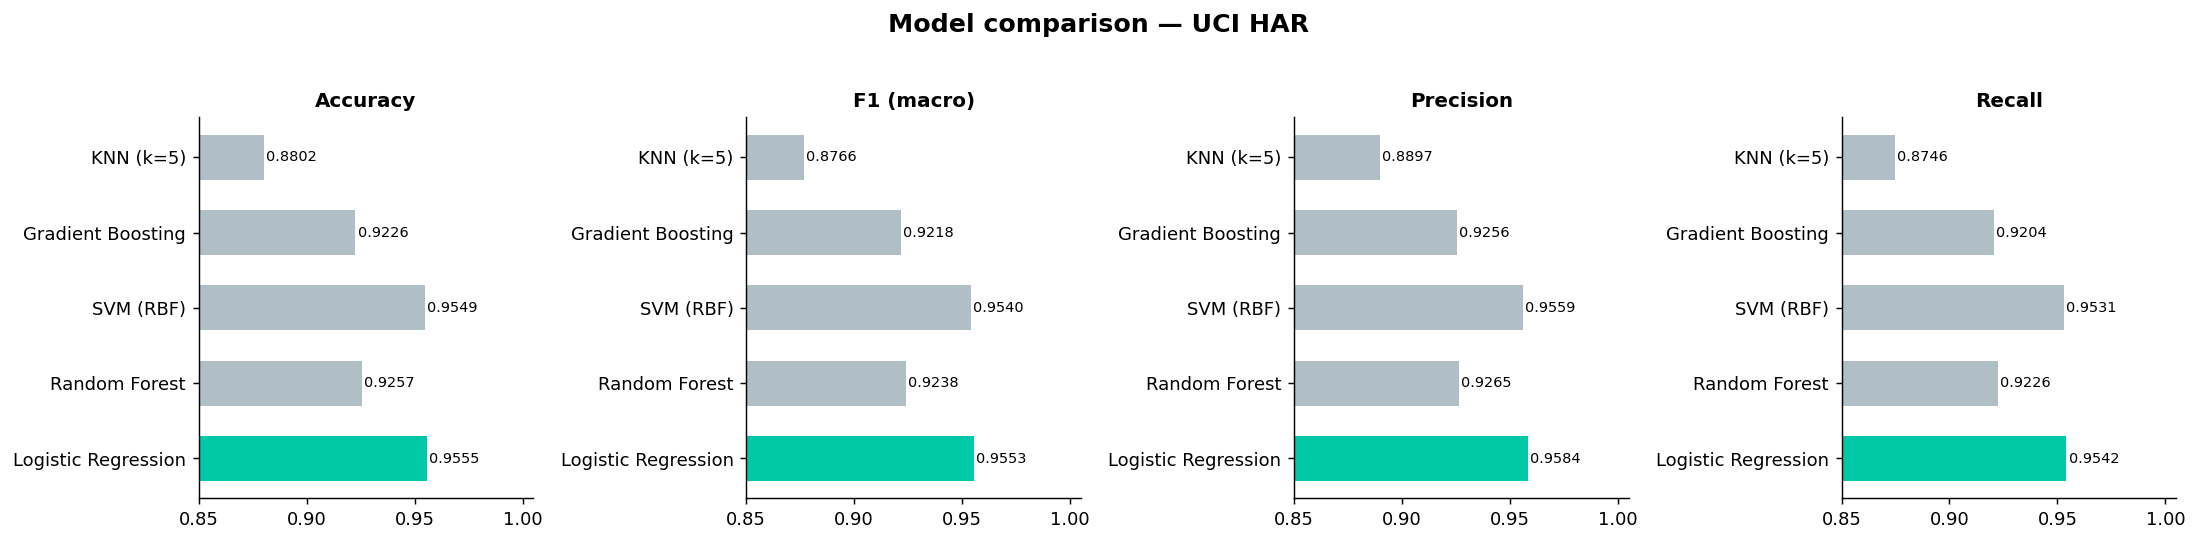

In [11]:
names   = list(results.keys())
metrics = ["accuracy", "f1_macro", "precision", "recall"]
labels  = ["Accuracy", "F1 (macro)", "Precision", "Recall"]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, metric, label in zip(axes, metrics, labels):
    vals   = [results[n][metric] for n in names]
    colors = ["#00C9A7" if v == max(vals) else "#B0BEC5" for v in vals]
    bars   = ax.barh(names, vals, color=colors, height=0.6, edgecolor="none")
    ax.set_xlim(0.85, 1.005)
    ax.set_title(label, fontsize=11, fontweight="bold")
    for bar, val in zip(bars, vals):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)
fig.suptitle("Model comparison — UCI HAR", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

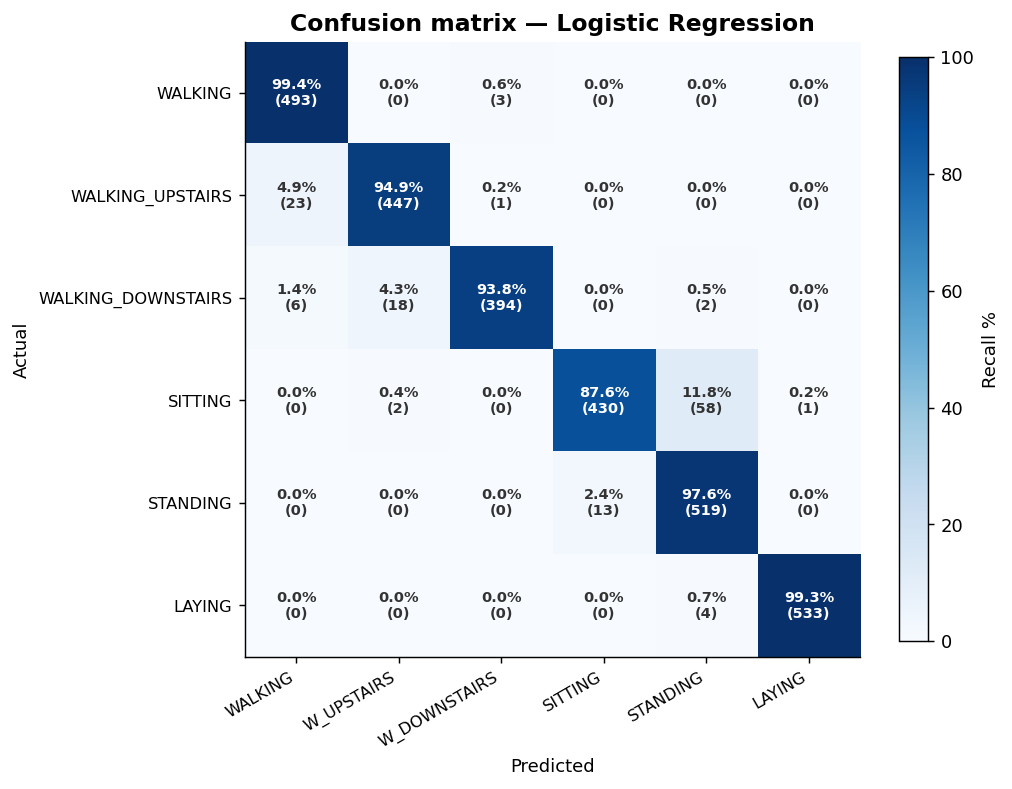

In [12]:
# ── 7b: Confusion matrix (best model) ────────────────────────────────────────
y_pred_best = results[best_name]["y_pred"]
cm     = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
for i in range(6):
    for j in range(6):
        color = "white" if cm_pct[i, j] > 50 else "#333"
        ax.text(j, i, f"{cm_pct[i,j]:.1f}%\n({cm[i,j]})",
                ha="center", va="center", color=color, fontsize=8, fontweight="bold")
short = [a.replace("WALKING_", "W_") for a in ACTIVITY_NAMES]
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(short, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ACTIVITY_NAMES, fontsize=9)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.75, label="Recall %")
plt.tight_layout()
plt.show()

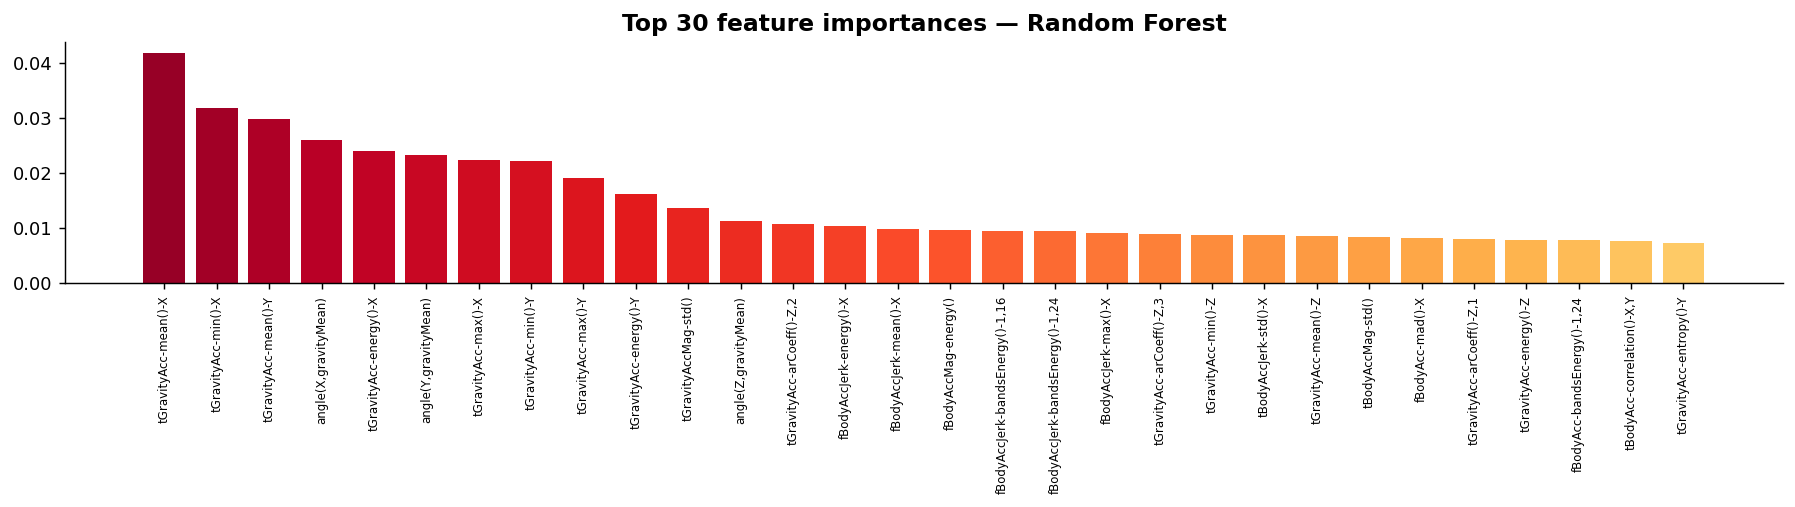

In [13]:
# ── 7c: Random Forest feature importances (top 30) ───────────────────────────
rf_pipe = results["Random Forest"]["pipeline"]
imp     = rf_pipe.named_steps["clf"].feature_importances_
idx     = np.argsort(imp)[::-1][:30]

fig, ax = plt.subplots(figsize=(14, 4))
colors  = plt.cm.YlOrRd(np.linspace(0.3, 0.95, 30))[::-1]
ax.bar(range(30), imp[idx], color=colors, edgecolor="none")
ax.set_xticks(range(30))
ax.set_xticklabels([feature_cols[i] for i in idx], rotation=90, fontsize=6.5)
ax.set_title("Top 30 feature importances — Random Forest",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
# ── 7d: Per-class classification report ──────────────────────────────────────
report = classification_report(y_test, y_pred_best,
                                target_names=ACTIVITY_NAMES, digits=4)
print(f"Model: {best_name}\n")
print(report)

Model: Logistic Regression

                    precision    recall  f1-score   support

           WALKING     0.9444    0.9940    0.9686       496
  WALKING_UPSTAIRS     0.9572    0.9490    0.9531       471
WALKING_DOWNSTAIRS     0.9899    0.9381    0.9633       420
           SITTING     0.9707    0.8758    0.9208       491
          STANDING     0.8902    0.9756    0.9309       532
            LAYING     0.9981    0.9926    0.9953       537

          accuracy                         0.9555      2947
         macro avg     0.9584    0.9542    0.9553      2947
      weighted avg     0.9573    0.9555    0.9555      2947



In [15]:
rows = []
for name, r in results.items():
    rows.append({"Model": name,
                 "Accuracy":  round(r["accuracy"],   5),
                 "F1_macro":  round(r["f1_macro"],   5),
                 "Precision": round(r["precision"],  5),
                 "Recall":    round(r["recall"],     5),
                 "Train_time_s": round(r["train_time"], 2)})

scores_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
scores_df.to_csv("/content/model_scores.csv", index=False)
print("Saved → /content/model_scores.csv")
scores_df.style.background_gradient(subset=["Accuracy","F1_macro"], cmap="Greens")

Saved → /content/model_scores.csv


,Model,Accuracy,F1_macro,Precision,Recall,Train_time_s
0,Logistic Regression,0.955550,0.955340,0.958430,0.954160,18.770000
2,SVM (RBF),0.954870,0.953950,0.955880,0.953090,32.050000
1,Random Forest,0.925690,0.923800,0.926510,0.922630,52.110000
3,Gradient Boosting,0.922630,0.921780,0.925610,0.920400,3552.800000
4,KNN (k=5),0.880220,0.876610,0.889700,0.874630,0.070000


In [16]:
def predict_samples(X: np.ndarray, model=None):
    """
    Run inference on an (n, 561) feature array.
    Returns a DataFrame with predicted activity and confidence.
    """
    if model is None:
        model = joblib.load(MODEL_PATH)
    preds  = model.predict(X)
    probs  = model.predict_proba(X) if hasattr(model, "predict_proba") else None
    rows   = []
    for i, pred in enumerate(preds):
        row = {"predicted_class": int(pred),
               "predicted_activity": ACTIVITY_NAMES[pred]}
        if probs is not None:
            row["confidence"] = f"{probs[i].max():.2%}"
        rows.append(row)
    return pd.DataFrame(rows)

# ── Demo: 15 random test-set samples ──────────────────────────────────────────
rng     = np.random.default_rng(7)
idx     = rng.choice(len(X_test), size=15, replace=False)
pred_df = predict_samples(X_test[idx])
pred_df["true_activity"] = [ACTIVITY_NAMES[y_test[i]] for i in idx]
pred_df["correct"]       = pred_df["predicted_activity"] == pred_df["true_activity"]
pred_df[["true_activity","predicted_activity","confidence","correct"]]

,true_activity,predicted_activity,confidence,correct
0,SITTING,SITTING,99.99%,True
1,STANDING,STANDING,99.98%,True
2,WALKING,WALKING,99.65%,True
3,LAYING,LAYING,99.98%,True
4,SITTING,SITTING,56.82%,True
5,STANDING,STANDING,99.76%,True
6,STANDING,STANDING,99.82%,True
7,WALKING_UPSTAIRS,WALKING_UPSTAIRS,99.59%,True
8,WALKING_UPSTAIRS,WALKING_UPSTAIRS,99.98%,True
9,STANDING,STANDING,99.63%,True


In [17]:
from google.colab import files

# Download best model
files.download(MODEL_PATH)

# Download scores CSV
files.download("/content/model_scores.csv")

print("✓ Downloads triggered.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads triggered.
